# Importing Libraries

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.config import *

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from sklearn.preprocessing import StandardScaler


from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)


from sklearn.pipeline import Pipeline


from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)


from sklearn.metrics import make_scorer, f1_score


import joblib

import warnings
warnings.filterwarnings("ignore")

In [19]:
pd.set_option(
    "display.max_colwidth",
    None
)

# Importing Dataset

In [6]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "breast_cancer.parquet")

TARGET_COL = "type"
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Full Dataset Shape: {X.shape}")

Full Dataset Shape: (151, 54675)


# Cross-Validation

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "logistic_regression": LogisticRegression(max_iter=5000, n_jobs=-1),
    "svm": SVC(kernel="rbf", probability=True),
    "random_forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "xgboost": XGBClassifier(random_state=42, eval_metric="mlogloss", n_jobs=-1),
    "lightgbm": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
}

# Benchmarking

In [20]:
results = []

for model_name, model in models.items():
    print(f"Running Cross-Validation for: {model_name}...")
    
    pipeline = Pipeline([
        ("feature_selection", SelectKBest(score_func=f_classif, k=1000)),
        
        ("scaler", StandardScaler()),
        
        ("model", model)
    ])
    
    scores = cross_validate(
        pipeline,
        X,
        y_encoded,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1_weighted": make_scorer(f1_score, average="weighted")
        },
        return_train_score=False,
        n_jobs=-1
    )
    
    results.append({
        "model": model_name,
        "mean_accuracy": scores["test_accuracy"].mean(),
        "std_accuracy": scores["test_accuracy"].std(),
        "mean_f1": scores["test_f1_weighted"].mean(),
        "std_f1": scores["test_f1_weighted"].std(),
        "fold_scores": scores["test_f1_weighted"]
    })
    
cv_results = pd.DataFrame(results)

cv_results["stability_score"] = (
    cv_results["mean_f1"] - cv_results["std_f1"]
)

cv_results = cv_results.sort_values(by="stability_score", ascending=False)
cv_results

Running Cross-Validation for: logistic_regression...
Running Cross-Validation for: svm...
Running Cross-Validation for: random_forest...
Running Cross-Validation for: xgboost...
Running Cross-Validation for: lightgbm...


,model,mean_accuracy,std_accuracy,mean_f1,std_f1,fold_scores,stability_score
2,random_forest,0.960215,0.032707,0.959528,0.033565,"[0.9675163546131288, 1.0, 0.966131907308378, 0.9664335664335665, 0.8975604787369493]",0.925963
1,svm,0.960215,0.049021,0.960061,0.049506,"[0.9680338636695373, 1.0, 0.9668376068376069, 1.0, 0.8654326066090773]",0.910555
0,logistic_regression,0.960215,0.049021,0.958787,0.051780,"[0.9680338636695373, 1.0, 1.0, 0.9664335664335665, 0.8594652406417113]",0.907007
3,xgboost,0.927312,0.024279,0.923289,0.024319,"[0.9025490638393865, 0.9664335664335665, 0.9174139585904293, 0.9307472919237625, 0.8993006993006993]",0.898969
4,lightgbm,0.934194,0.045940,0.928047,0.044787,"[0.8694037145650049, 1.0, 0.9512820512820513, 0.9199134199134199, 0.8996361808126514]",0.883260


# Fold Analysis & Plotting

Saved stability plot to artifacts.


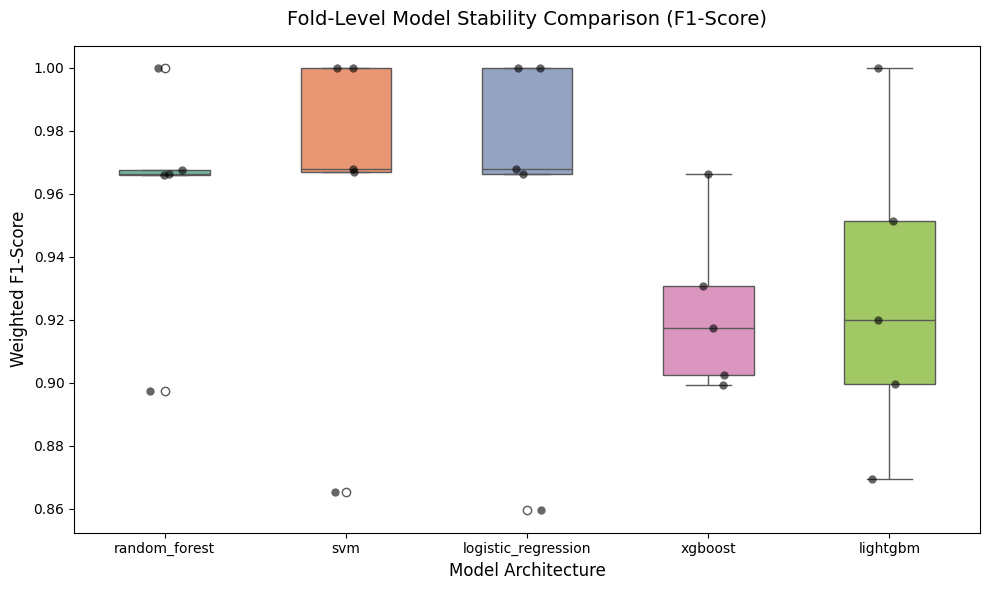

In [24]:
fold_data = []
for _, row in cv_results.iterrows():
    for fold_score in row["fold_scores"]:
        fold_data.append({
            "model": row["model"],
            "f1_score": fold_score
        })
fold_df = pd.DataFrame(fold_data)

plt.figure(figsize=(10, 6))
sns.boxplot(data=fold_df, x="model", y="f1_score", palette="Set2", width=0.5)
sns.stripplot(data=fold_df, x="model", y="f1_score", color="black", alpha=0.6, size=6, jitter=0.1)

plt.title("Fold-Level Model Stability Comparison (F1-Score)", fontsize=14, pad=15)
plt.ylabel("Weighted F1-Score", fontsize=12)
plt.xlabel("Model Architecture", fontsize=12)
plt.tight_layout()

plt.savefig(ARTIFACT_DIR / "model_stability_cv.png", dpi=300)
print("Saved stability plot to artifacts.")

"""
Interpretation:

- Random Forest demonstrates the strongest
  stability-performance tradeoff.

- SVM achieves similarly high performance
  but exhibits slightly higher variance.

- Boosting models show reduced robustness
  on this small high-dimensional dataset.

- Results suggest that simpler ensemble
  methods generalize better for this
  genomics classification problem.
"""

# Confirming Best Model

In [25]:
best_model_name = cv_results.sort_values(
    by="stability_score",
    ascending=False
).iloc[0]["model"]

best_model_name

'random_forest'

In [26]:
best_model = models[best_model_name]

# Final Pipeline

In [28]:
# Define the final production pipeline using our best model configuration
final_pipeline = Pipeline([
    ("feature_selection", SelectKBest(score_func=f_classif, k=1000)),
    ("scaler", StandardScaler()),
    ("model", best_model)
])

print("Fitting the final pipeline on the entire dataset...")
final_pipeline.fit(X, y_encoded)
print("Pipeline successfully fitted!")

Fitting the final pipeline on the entire dataset...
Pipeline successfully fitted!


# Saving artifacts & model

In [29]:
# 1. Save the fitted production pipeline
joblib.dump(final_pipeline, MODEL_DIR / "validated_final_model.pkl")

# 2. Save the cross-validation metrics dataframe
cv_results.to_parquet(ARTIFACT_DIR / "cv_results.parquet", index=False)

# 3. Save the label encoder mapping for decoding downstream
joblib.dump(label_encoder, ARTIFACT_DIR / "cv_label_encoder.pkl")

print("All pipeline artifacts have been successfully exported!")

All pipeline artifacts have been successfully exported!
